<a href="https://colab.research.google.com/github/Likitha-sd/Predicting_Housing_Price_California_Distirct_using_Regressoin/blob/main/California_house_price_predictions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importing the libraries
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
print("sucessful")

sucessful


In [ ]:
#load the load
data=pd.read_csv("housing.csv")
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
data.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [ ]:
# TO check the null values
data.isnull().sum()


,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [ ]:
# to get the count of values
data['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [ ]:
# randomising the values , to make sure not to be in order

data_rd=data.sample(n=len(data),random_state=1)
data_rd

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
4712,-118.36,34.06,39.0,2810.0,670.0,1109.0,624.0,3.2500,355000.0,<1H OCEAN
2151,-119.78,36.78,37.0,2185.0,455.0,1143.0,438.0,1.9784,70700.0,INLAND
15927,-122.42,37.73,46.0,1819.0,411.0,1534.0,406.0,4.0132,229400.0,NEAR BAY
82,-122.28,37.81,52.0,340.0,97.0,200.0,87.0,1.5208,112500.0,NEAR BAY
8161,-118.13,33.82,37.0,1530.0,290.0,711.0,283.0,5.1795,225400.0,<1H OCEAN
...,...,...,...,...,...,...,...,...,...,...
10955,-117.88,33.76,17.0,1768.0,474.0,1079.0,436.0,1.7823,205300.0,<1H OCEAN
17289,-119.63,34.42,42.0,1765.0,263.0,753.0,260.0,8.5608,500001.0,<1H OCEAN
5192,-118.26,33.93,42.0,1433.0,295.0,775.0,293.0,1.1326,104800.0,<1H OCEAN
12172,-117.16,33.73,10.0,2381.0,454.0,1323.0,477.0,2.6322,140700.0,INLAND


In [ ]:
# get the word to int through gummies -one hot encoding

pd.get_dummies(data_rd['ocean_proximity']).astype(int).head()


,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
4712,1,0,0,0,0
2151,0,1,0,0,0
15927,0,0,0,1,0
82,0,0,0,1,0
8161,1,0,0,0,0


In [ ]:
# Drop the words to int

data_rd.drop('ocean_proximity',axis=1)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
4712,-118.36,34.06,39.0,2810.0,670.0,1109.0,624.0,3.2500,355000.0
2151,-119.78,36.78,37.0,2185.0,455.0,1143.0,438.0,1.9784,70700.0
15927,-122.42,37.73,46.0,1819.0,411.0,1534.0,406.0,4.0132,229400.0
82,-122.28,37.81,52.0,340.0,97.0,200.0,87.0,1.5208,112500.0
8161,-118.13,33.82,37.0,1530.0,290.0,711.0,283.0,5.1795,225400.0
...,...,...,...,...,...,...,...,...,...
10955,-117.88,33.76,17.0,1768.0,474.0,1079.0,436.0,1.7823,205300.0
17289,-119.63,34.42,42.0,1765.0,263.0,753.0,260.0,8.5608,500001.0
5192,-118.26,33.93,42.0,1433.0,295.0,775.0,293.0,1.1326,104800.0
12172,-117.16,33.73,10.0,2381.0,454.0,1323.0,477.0,2.6322,140700.0


In [ ]:
# After one hot encoding, adding them to original dataset

data_final=pd.concat([data_rd.drop('ocean_proximity',axis=1),pd.get_dummies(data_rd["ocean_proximity"]).astype(int)],axis=1)
data_final

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
4712,-118.36,34.06,39.0,2810.0,670.0,1109.0,624.0,3.2500,355000.0,1,0,0,0,0
2151,-119.78,36.78,37.0,2185.0,455.0,1143.0,438.0,1.9784,70700.0,0,1,0,0,0
15927,-122.42,37.73,46.0,1819.0,411.0,1534.0,406.0,4.0132,229400.0,0,0,0,1,0
82,-122.28,37.81,52.0,340.0,97.0,200.0,87.0,1.5208,112500.0,0,0,0,1,0
8161,-118.13,33.82,37.0,1530.0,290.0,711.0,283.0,5.1795,225400.0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10955,-117.88,33.76,17.0,1768.0,474.0,1079.0,436.0,1.7823,205300.0,1,0,0,0,0
17289,-119.63,34.42,42.0,1765.0,263.0,753.0,260.0,8.5608,500001.0,1,0,0,0,0
5192,-118.26,33.93,42.0,1433.0,295.0,775.0,293.0,1.1326,104800.0,1,0,0,0,0
12172,-117.16,33.73,10.0,2381.0,454.0,1323.0,477.0,2.6322,140700.0,0,1,0,0,0


In [ ]:
# Feature Selection

data_final=data_final[['longitude',	'latitude',
                                     'housing_median_age',	'total_rooms',
                                     'total_bedrooms',	'population',
                                     'households',	'median_income',
                                     '<1H OCEAN',
                                     'INLAND',	'ISLAND',
                                     'NEAR BAY',	'NEAR OCEAN', 'median_house_value']]
data_final

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,median_house_value
4712,-118.36,34.06,39.0,2810.0,670.0,1109.0,624.0,3.2500,1,0,0,0,0,355000.0
2151,-119.78,36.78,37.0,2185.0,455.0,1143.0,438.0,1.9784,0,1,0,0,0,70700.0
15927,-122.42,37.73,46.0,1819.0,411.0,1534.0,406.0,4.0132,0,0,0,1,0,229400.0
82,-122.28,37.81,52.0,340.0,97.0,200.0,87.0,1.5208,0,0,0,1,0,112500.0
8161,-118.13,33.82,37.0,1530.0,290.0,711.0,283.0,5.1795,1,0,0,0,0,225400.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10955,-117.88,33.76,17.0,1768.0,474.0,1079.0,436.0,1.7823,1,0,0,0,0,205300.0
17289,-119.63,34.42,42.0,1765.0,263.0,753.0,260.0,8.5608,1,0,0,0,0,500001.0
5192,-118.26,33.93,42.0,1433.0,295.0,775.0,293.0,1.1326,1,0,0,0,0,104800.0
12172,-117.16,33.73,10.0,2381.0,454.0,1323.0,477.0,2.6322,0,1,0,0,0,140700.0


In [ ]:
# Remove Null values

data_final=data_final.dropna()
len(data_final)

20433

In [ ]:
# Data splitting

train_pd,valid_pd,test_pd=data_final[:18000],data_final[18000:19217],data_final[19215:]

In [ ]:
len(train_pd),len(valid_pd),len(test_pd)

(18000, 1217, 1218)

In [ ]:
# Train_test_split

X_train,y_train=train_pd.drop('median_house_value',axis=1),train_pd['median_house_value']
X_valid,y_valid=valid_pd.drop('median_house_value',axis=1),valid_pd['median_house_value']
X_test,y_test=test_pd.drop('median_house_value',axis=1),test_pd['median_house_value']

# shape

X_train.shape,y_train.shape,X_valid.shape,y_valid.shape,X_test.shape,y_test.shape


((18000, 13), (18000,), (1217, 13), (1217,), (1218, 13), (1218,))

In [ ]:
# Transforming the values - 8 cols

from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()
X_train_scalar=scalar.fit_transform(X_train.iloc[:,:8])
X_valid_scalar=scalar.transform(X_valid.iloc[:,:8])
X_test_scalar=scalar.transform(X_test.iloc[:,:8])

# shape

X_train_scalar.shape,X_valid_scalar.shape,X_test_scalar.shape

((18000, 8), (1217, 8), (1218, 8))

In [ ]:
# To get all columns after scaling only 8 cols - 13 cols

# the first 8 cols form scaling

X_train_cat = X_train.iloc[:, 8:]
X_valid_cat = X_valid.iloc[:, 8:]
X_test_cat  = X_test.iloc[:, 8:]

# creating the new array

X_train_final = np.hstack([X_train_scalar, X_train_cat])
X_valid_final = np.hstack([X_valid_scalar, X_valid_cat])
X_test_final  = np.hstack([X_test_scalar, X_test_cat])

print(X_train_final.shape, X_valid_final.shape, X_test_final.shape)


(18000, 13) (1217, 13) (1218, 13)


array([[<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>,
        <Axes: title={'center': '2'}>, <Axes: title={'center': '3'}>],
       [<Axes: title={'center': '4'}>, <Axes: title={'center': '5'}>,
        <Axes: title={'center': '6'}>, <Axes: title={'center': '7'}>],
       [<Axes: title={'center': '8'}>, <Axes: title={'center': '9'}>,
        <Axes: title={'center': '10'}>, <Axes: title={'center': '11'}>],
       [<Axes: title={'center': '12'}>, <Axes: >, <Axes: >, <Axes: >]],
      dtype=object)

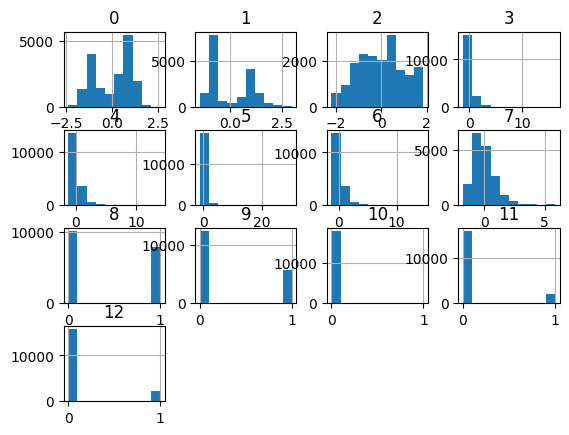

In [ ]:
pd.DataFrame(X_train_final).hist()

In [ ]:
# Linear Regression Model

from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.linear_model import LinearRegression

lm=LinearRegression()
lm.fit(X_train_final,y_train)

train_rmse  = rmse(y_train, lm.predict(X_train_final))
valid_rmse = rmse(y_valid, lm.predict(X_valid_final))
test_rmse = rmse(y_test, lm.predict(X_test_final))

train_rmse, valid_rmse,test_rmse

(68593.05578127236, 66530.41705120307, 71382.43558330165)

In [ ]:
# K Nearest Neighbors Model

from sklearn.neighbors import KNeighborsRegressor

knn=KNeighborsRegressor(n_neighbors=10)
knn.fit(X_train_final,y_train)

train_rmse  = rmse(y_train, knn.predict(X_train_final))
valid_rmse = rmse(y_valid, knn.predict(X_valid_final))
test_rmse = rmse(y_test, knn.predict(X_test_final))

train_rmse, valid_rmse,test_rmse


(53759.09908812057, 58193.331751442405, 62161.22860469906)

In [ ]:
#  Random Forest Model

from sklearn.ensemble import RandomForestRegressor

rfr=RandomForestRegressor(max_depth=10)
rfr.fit(X_train_final,y_train)

train_rmse  = rmse(y_train, rfr.predict(X_train_final))
valid_rmse = rmse(y_valid, rfr.predict(X_valid_final))
test_rmse = rmse(y_test, rfr.predict(X_test_final))

train_rmse, valid_rmse,test_rmse



(43559.92423488218, 52143.03421878993, 53390.8664407645)

In [ ]:
# Gradient Boosting Model

from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(n_estimators=250)
gbr.fit(X_train_final, y_train)

train_rmse  = rmse(y_train, gbr.predict(X_train_final))
valid_rmse = rmse(y_valid, gbr.predict(X_valid_final))
test_rmse = rmse(y_test, gbr.predict(X_test_final))

train_rmse, valid_rmse,test_rmse


(47274.82259072158, 49263.862249314734, 51411.75619545966)